In [ ]:
import pandas as pd

# Carica il dataset
df = pd.read_csv('train_Titanic.csv')

# Visualizza le prime 5 righe per controllare che sia tutto ok
print(df.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  


In [ ]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [ ]:
df.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   PassengerId   8693 non-null   category
 1   HomePlanet    8492 non-null   category
 2   CryoSleep     8476 non-null   category
 3   Cabin         8494 non-null   category
 4   Destination   8511 non-null   category
 5   Age           8514 non-null   float64 
 6   VIP           8490 non-null   category
 7   RoomService   8512 non-null   float64 
 8   FoodCourt     8510 non-null   float64 
 9   ShoppingMall  8485 non-null   float64 
 10  Spa           8510 non-null   float64 
 11  VRDeck        8505 non-null   float64 
 12  Name          8493 non-null   category
 13  Transported   8693 non-null   bool    
dtypes: bool(1), category(7), float64(6)
memory usage: 686.4 KB


C:\Users\User_Valerio\AppData\Local\Temp\ipykernel_8160\703707704.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


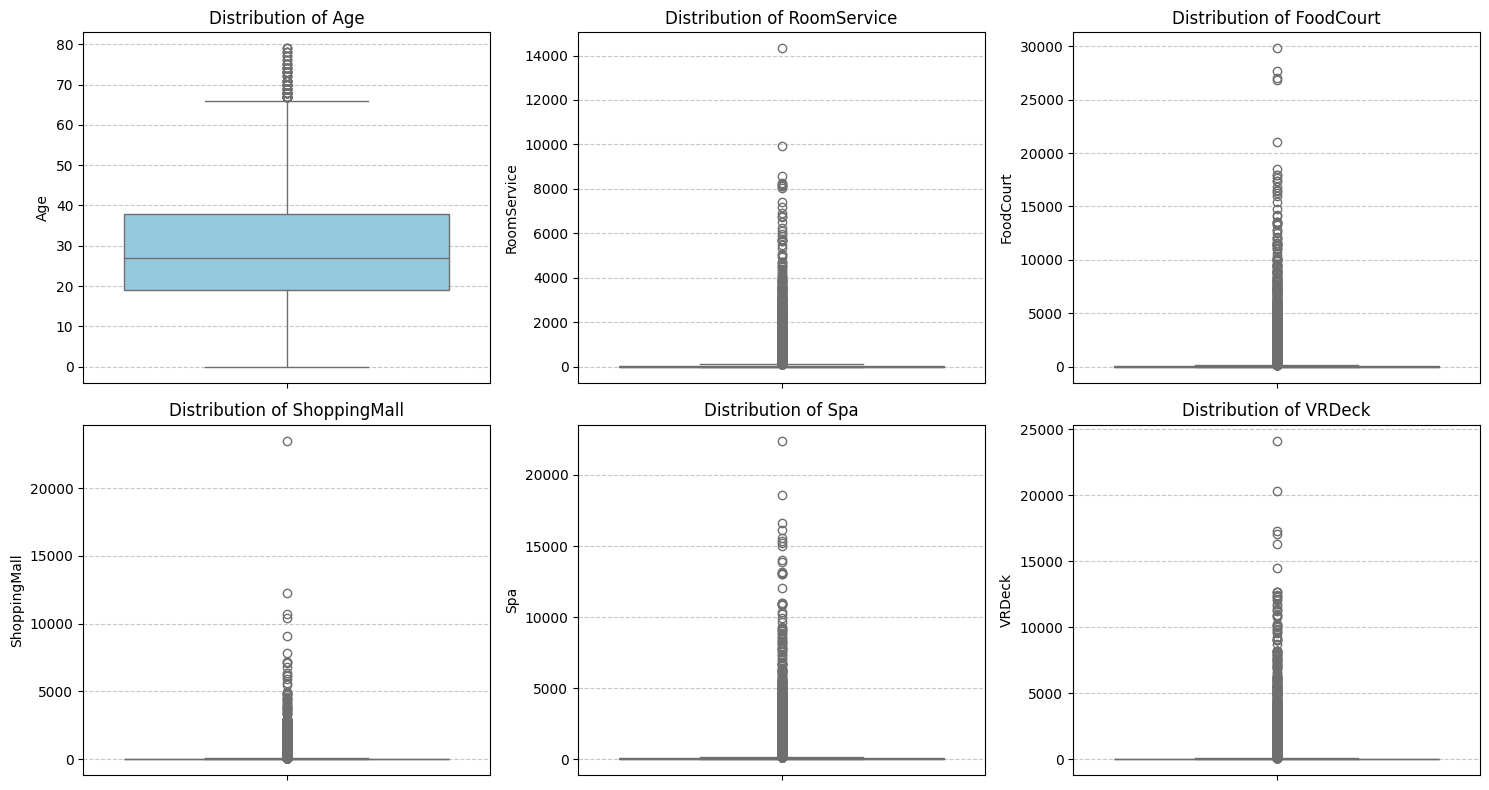

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# 2. Setup the grid dimensions (e.g., 3 columns per row)
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

# 3. Create the figure
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df, y=col, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Final adjustments and saving
plt.tight_layout()

In [ ]:
# 1. Isola il target (y)
y = df['Transported'].copy()

# 2. Rimuovi il target dal DataFrame principale per creare il set delle caratteristiche (X)
X = df.drop(columns=['Transported'])

# 3. Stampa le dimensioni per verifica
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (8693, 13)
Target shape: (8693,)


In [ ]:
# 1. Creiamo prima la colonna delle spese totali (necessaria per i calcoli successivi)
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
X['TotalSpending'] = X[spending_cols].sum(axis=1)

# 2. Spending per Year of Age (Adattamento di Avg_Monthly_Spend)
# Usiamo Age + 1 per evitare la divisione per zero (per i neonati/bambini di 0 anni)
X['Spending_per_Age'] = X['TotalSpending'] / (X['Age'] + 1)

# 3. Luxury Ratio (Adattamento di Charge_Ratio)
# Vediamo quanta percentuale della spesa totale è andata in Spa e VRDeck (servizi di lusso)
# Aggiungiamo 0.01 al denominatore per evitare divisioni per zero se TotalSpending è 0
X['Luxury_Ratio'] = (X['Spa'] + X['VRDeck']) / (X['TotalSpending'] + 0.01)

# Verifichiamo le nuove colonne
print(X[['TotalSpending', 'Spending_per_Age', 'Luxury_Ratio']].head())

X['Group'] = X['PassengerId'].str.split('_').str[0]   # identifica famiglie/gruppi
group_sizes = X.groupby('Group')['PassengerId'].transform('count')
X['GroupSize'] = group_sizes

# Interazioni utile per il modello
'''X['CryoVIP'] = X['CryoSleep'] * X['VIP']
X['Luxury_per_Age'] = X['Spending_per_Age'] * X['Luxury_Ratio']
X['GroupSpending'] = X['GroupSize'] * X['TotalSpending']'''

# 1. Interazione Categorica: estraiamo i numeri (cat.codes) per fare la moltiplicazione
X['CryoVIP'] = X['CryoSleep'].astype('category').cat.codes * X['VIP'].astype('category').cat.codes

# 2. Interazioni Numeriche: queste funzionano direttamente perché sono già numeri (float)
X['Luxury_per_Age'] = X['Spending_per_Age'] * X['Luxury_Ratio']

# 3. Attenzione al nome della colonna: avevamo usato Group_Size
X['GroupSpending'] = X['GroupSize'] * X['TotalSpending']

   TotalSpending  Spending_per_Age  Luxury_Ratio
0            0.0          0.000000      0.000000
1          736.0         29.440000      0.805696
2        10383.0        175.983051      0.651449
3         5176.0        152.235294      0.680447
4         1091.0         64.176471      0.519702


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# --- 0. FEATURE ENGINEERING (Per alzare l'Accuracy) ---
# Sblocchiamo la cabina e la dividiamo per non perdere i dati
df['Cabin'] = df['Cabin'].astype(object).fillna('Z/9999/Z')
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)

# Estraiamo i gruppi dall'ID
df['Group'] = df['PassengerId'].apply(lambda x: str(x).split('_')[0])
df['Group_Size'] = df.groupby('Group')['Group'].transform('count')

# Aggiungiamo le nuove informazioni a X
X['Deck'] = df['Deck']
X['Side'] = df['Side']
X['Group_Size'] = df['Group_Size']

# Puliamo le colonne inutili per non confondere il modello
X = X.drop(columns=['Cabin', 'PassengerId', 'Name', 'Group', 'Num'], errors='ignore')

# --- 1. PREPARE DATA E FIX CATEGORIE ---
# Il tuo fix geniale, ma fatto su tutto X *prima* dello split per evitare mismatch
for col in X.select_dtypes(include=['object', 'category', 'bool']).columns:
    X[col] = X[col].astype('category').cat.codes

# Fix per il target: forziamo a intero (0 o 1) per evitare il bug numpy.bool
y_numeric = y.astype(int)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_numeric, test_size=0.2, random_state=42, stratify=y_numeric
)

# Avendo usato cat.codes, enable_categorical non è più obbligatorio (tutto è già numerico)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# --- FIX ERRORE NUMPY.BOOL ---
# Sostituiamo i len() con la somma matematica (.sum()), che non fallisce mai
conto_0 = (y_train == 0).sum()
conto_1 = (y_train == 1).sum()
ratio = conto_0 / conto_1

# --- 2. OPTUNA & XGBOOST ---
def objective(trial):
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'n_jobs' : -1,
        
        # Hyperparameters
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', ratio * 0.8, ratio * 1.2),
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }

    # FIX ERRORE "ModuleNotFoundError": 
    # Abbiamo rimosso 'optuna.integration.XGBoostPruningCallback'.
    # Usiamo invece 'early_stopping_rounds' nativo di XGBoost che è più sicuro e previene l'overfitting.
    
    bst = xgb.train(
        param, 
        dtrain, 
        num_boost_round=1500, # Numero alto, si fermerà da solo quando l'accuracy non migliora
        evals=[(dtrain, 'train'), (dtest, 'eval')],
        early_stopping_rounds=50, 
        verbose_eval=False
    )
    
    # Predict and convert probabilities to binary (0 or 1)
    preds_prob = bst.predict(dtest)
    preds = [1 if p > 0.5 else 0 for p in preds_prob]
    
    return f1_score(y_test, preds)

# --- 3. RUN THE OPTUNA STUDY ---
optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction='maximize')

# Impostato su 50 n_trials per trovare i parametri "perfetti"
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n🚀 Best F1-Score: {study.best_trial.value:.4f}")
print(f"⚙️ Best parameters: {study.best_params}")

[I 2026-03-04 16:43:49,499] A new study created in memory with name: no-name-01ba7e21-9cb2-43d0-adcc-8716ad30fa05
Best trial: 0. Best value: 0.809229:   2%|▏         | 1/50 [00:01<00:52,  1.07s/it]

[I 2026-03-04 16:43:50,567] Trial 0 finished with value: 0.8092290377039955 and parameters: {'scale_pos_weight': 0.9944019145665214, 'lambda': 9.286623782776976e-07, 'alpha': 0.014277009236335207, 'subsample': 0.7006194930388862, 'colsample_bytree': 0.8478230470875914, 'max_depth': 6, 'learning_rate': 0.03132836637206007, 'min_child_weight': 5}. Best is trial 0 with value: 0.8092290377039955.


Best trial: 0. Best value: 0.809229:   4%|▍         | 2/50 [00:01<00:38,  1.23it/s]

[I 2026-03-04 16:43:51,197] Trial 1 finished with value: 0.801605504587156 and parameters: {'scale_pos_weight': 1.0126624677289384, 'lambda': 0.0006558251463609785, 'alpha': 0.00013419468533297204, 'subsample': 0.7410319098978664, 'colsample_bytree': 0.9267282642591848, 'max_depth': 9, 'learning_rate': 0.08643144216199988, 'min_child_weight': 4}. Best is trial 0 with value: 0.8092290377039955.


Best trial: 0. Best value: 0.809229:   6%|▌         | 3/50 [00:02<00:44,  1.05it/s]

...

[I 2026-03-04 16:46:15,155] Trial 47 finished with value: 0.8167597765363128 and parameters: {'scale_pos_weight': 1.1144986620684219, 'lambda': 0.9175912331031625, 'alpha': 1.1235574393586026e-06, 'subsample': 0.9762332968058716, 'colsample_bytree': 0.5451882067321469, 'max_depth': 9, 'learning_rate': 0.013608267557389326, 'min_child_weight': 8}. Best is trial 31 with value: 0.8229508196721311.


Best trial: 31. Best value: 0.822951:  98%|█████████▊| 49/50 [02:27<00:03,  3.51s/it]

[I 2026-03-04 16:46:16,726] Trial 48 finished with value: 0.8076923076923077 and parameters: {'scale_pos_weight': 1.026759395207417, 'lambda': 6.372662704128882e-08, 'alpha': 0.48592403861031286, 'subsample': 0.9761325568260494, 'colsample_bytree': 0.6164011136681359, 'max_depth': 8, 'learning_rate': 0.04216386383169528, 'min_child_weight': 9}. Best is trial 31 with value: 0.8229508196721311.


Best trial: 31. Best value: 0.822951: 100%|██████████| 50/50 [02:29<00:00,  2.98s/it]

[I 2026-03-04 16:46:18,725] Trial 49 finished with value: 0.819078947368421 and parameters: {'scale_pos_weight': 1.1568205267777305, 'lambda': 0.09188306322583875, 'alpha': 0.00577566891688208, 'subsample': 0.9168624999545407, 'colsample_bytree': 0.6490783412521172, 'max_depth': 4, 'learning_rate': 0.03208872509025029, 'min_child_weight': 10}. Best is trial 31 with value: 0.8229508196721311.

🚀 Best F1-Score: 0.8230
⚙️ Best parameters: {'scale_pos_weight': 1.1436335515797205, 'lambda': 0.051110771406112226, 'alpha': 0.019944629466718444, 'subsample': 0.9592450432238729, 'colsample_bytree': 0.6827396168876156, 'max_depth': 3, 'learning_rate': 0.011564413217802248, 'min_child_weight': 7}


In [ ]:
'''df = df.drop('PassengerId', axis=1)
df.info()'''

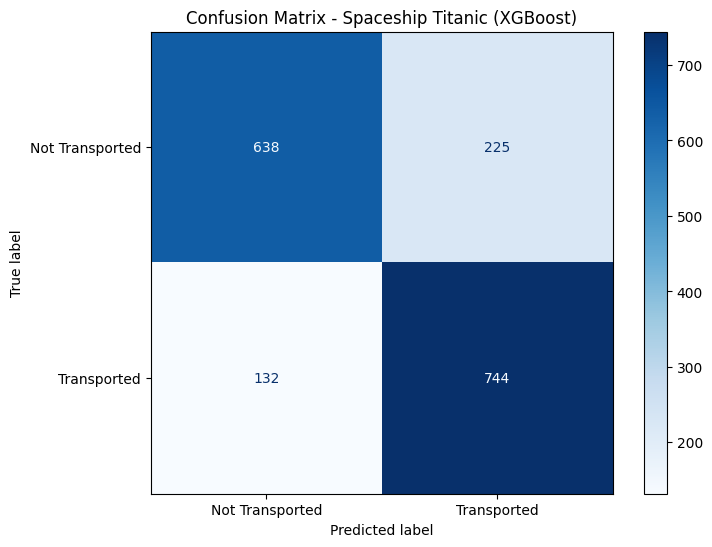


--- CLASSIFICATION REPORT ---
                 precision    recall  f1-score   support

Not Transported       0.83      0.74      0.78       863
    Transported       0.77      0.85      0.81       876

       accuracy                           0.79      1739
      macro avg       0.80      0.79      0.79      1739
   weighted avg       0.80      0.79      0.79      1739



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# --- 4. MODELLO FINALE E VALUTAZIONE ---

# Recuperiamo i parametri migliori appena trovati da Optuna
best_params = study.best_params

# Riaggiungiamo i parametri strutturali obbligatori
best_params.update({
    'tree_method': 'hist',
    'objective': 'binary:logistic',
    'n_jobs': -1
})

# Creiamo il modello finale usando l'interfaccia XGBClassifier (come fa il prof)
final_model = xgb.XGBClassifier(**best_params)

# Addestriamo il modello finale sui dati di training
final_model.fit(X_train, y_train)

# Facciamo le previsioni sul set di test (quello che il modello non ha mai visto)
y_pred = final_model.predict(X_test)

# --- MATRICE DI CONFUSIONE ---
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Attenzione qui: cambiamo le etichette da 'Churn' a 'Transported'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Transported', 'Transported'])
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix - Spaceship Titanic (XGBoost)')
plt.show()

# --- REPORT DETTAGLIATO DELLE METRICHE ---
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Not Transported', 'Transported']))